### Data Synthesis for Damped Harmonic Oscilator

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# SHO parameters
A = 32         # amplitude
gamma = 0.1
omega_0 = 3.0
omega_d = 6.0
phi = 0.0
noise_std = 0.02*A  # std dev of Gaussian noise

# Time vector
t_start, t_end, n_points = 0, 10, 500
t = np.linspace(t_start, t_end, n_points)


$
x\left(t\right) = A\exp(-\gamma\omega_0t)\cos\left(\omega_d t- \phi\right)
$

In [2]:
# Clean displacement: x(t) = A cos(omega t + phi)
x_clean = A * np.exp(-gamma * omega_0 * t) * np.cos(omega_d * t - phi)

# Add Gaussian noise
rng = np.random.default_rng(seed=42)
noise = rng.normal(loc=0.0, scale=noise_std, size=t.shape)
x_noisy = x_clean + noise

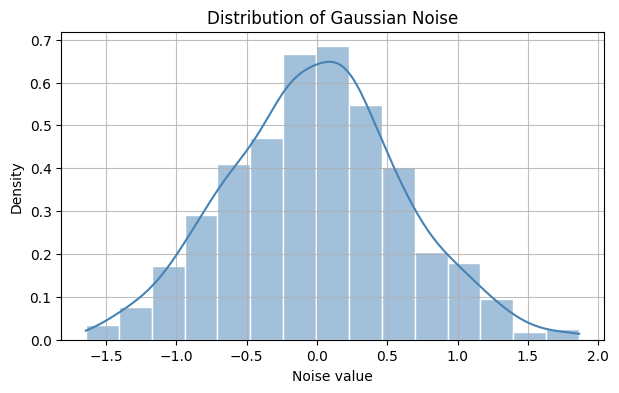

In [3]:
import seaborn as sns
plt.figure(figsize=(7, 4))
sns.histplot(noise, kde=True, stat="density", bins=15, color="steelblue", edgecolor="white")
plt.xlabel("Noise value")
plt.ylabel("Density")
plt.title("Distribution of Gaussian Noise")
plt.grid(alpha=0.8)
plt.show()

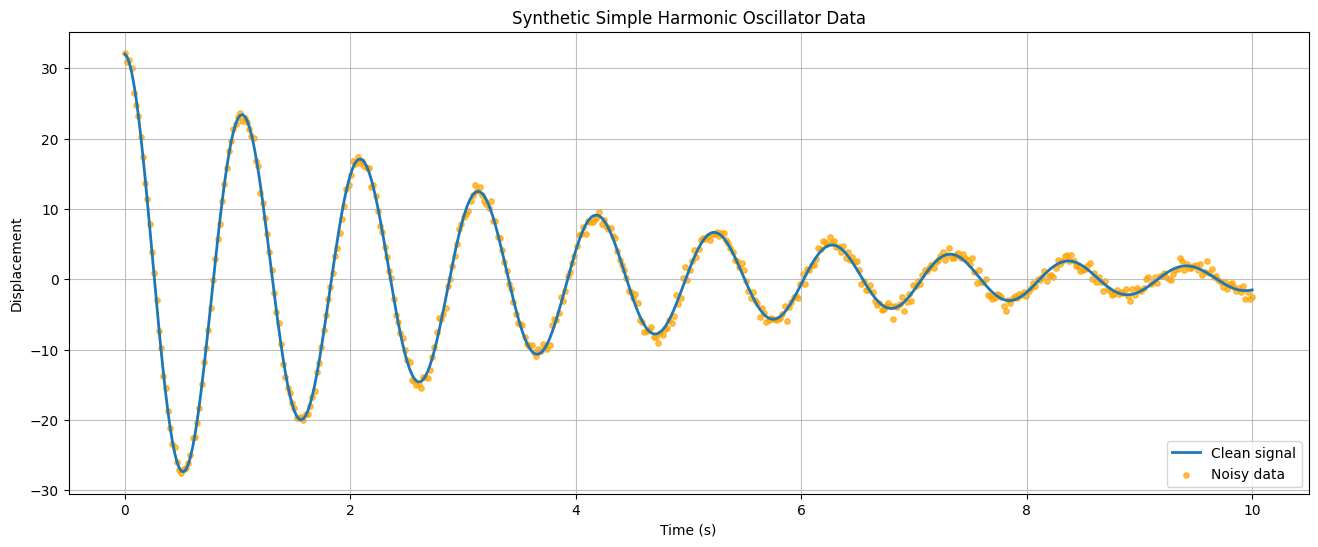

In [5]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(t, x_clean, label="Clean signal", linewidth=2)
ax.scatter(t, x_noisy, color="orange", s=15, label="Noisy data", alpha=0.7)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement")
ax.set_title("Synthetic Simple Harmonic Oscillator Data")
ax.legend(loc="lower right")
ax.grid(alpha=0.8)

### Simple ANN approach to attempt modelling the SHO

In [6]:
import torch
import torch.nn as nn

# Convert data to tensors (reshape to column vectors)
t_tensor = torch.tensor(t, dtype=torch.float32).reshape(-1, 1)
x_tensor = torch.tensor(x_noisy, dtype=torch.float32).reshape(-1, 1)

# Normalize inputs
t_mean, t_std = t_tensor.mean(), t_tensor.std()
#t_mean, t_std = torch.tensor(0.0), torch.tensor(1.0) # Un-normalization
t_norm = (t_tensor - t_mean) / t_std

# Normalize targets
x_mean, x_std = x_tensor.mean(), x_tensor.std()
#x_mean, x_std = torch.tensor(0.0), torch.tensor(1.0) # Un-normalization
x_norm = (x_tensor - x_mean) / x_std

In [7]:
class SHONet(nn.Module):
    def __init__(self, hidden_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.net(x)

model = SHONet()

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

n_epochs = 3000
loss = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    pred = model(t_norm)
    loss = criterion(pred, x_norm)   # compare in normalized space
    loss.backward()
    optimizer.step()
    loss.append(loss.item())

    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.6f}")

Epoch 200/3000, Loss: 0.993933
Epoch 400/3000, Loss: 0.233147
Epoch 600/3000, Loss: 0.097653
Epoch 800/3000, Loss: 0.040713
Epoch 1000/3000, Loss: 0.022109
Epoch 1200/3000, Loss: 0.013374
Epoch 1400/3000, Loss: 0.010110
Epoch 1600/3000, Loss: 0.016631
Epoch 1800/3000, Loss: 0.009176
Epoch 2000/3000, Loss: 0.008347
Epoch 2200/3000, Loss: 0.021836
Epoch 2400/3000, Loss: 0.006765
Epoch 2600/3000, Loss: 0.003984
Epoch 2800/3000, Loss: 0.003856
Epoch 3000/3000, Loss: 0.004112


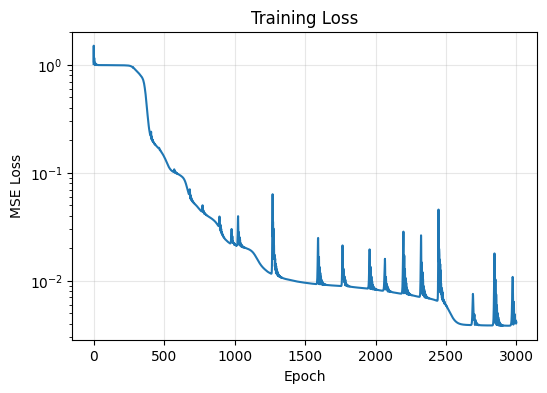

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(loss)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.show()

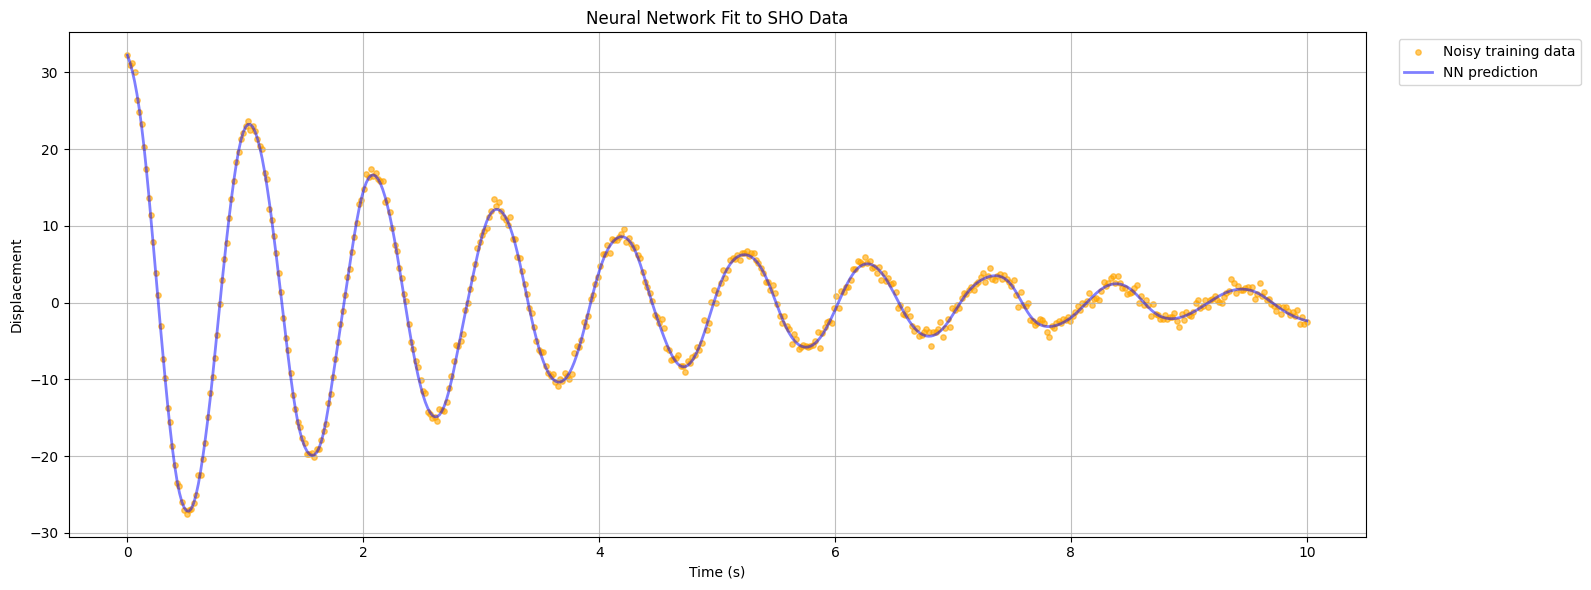

In [11]:
model.eval()
with torch.no_grad():
    t_fine = np.linspace(t_start, t_end, 500)
    t_fine_tensor = torch.tensor(t_fine, dtype=torch.float32).reshape(-1, 1)
    t_fine_norm = (t_fine_tensor - t_mean) / t_std

    x_pred_norm = model(t_fine_norm)
    x_pred = (x_pred_norm * x_std + x_mean).numpy().flatten()  # <-- unnormalize

x_true_fine = A * np.exp(-gamma * omega_0 * t_fine) * np.cos(omega_d * t_fine - phi)

fig, ax = plt.subplots(figsize=(16, 6))
ax.scatter(t, x_noisy, s=15, color="orange", alpha=0.6, label="Noisy training data")
ax.plot(t_fine, x_pred, color="blue", linewidth=2, alpha = 0.5, label="NN prediction")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement")
ax.set_title("Neural Network Fit to SHO Data")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.grid(alpha=0.8)
plt.show()

**Observations**:

When data is not normalized:
- The larger the amplitude, a good fit requires a larger quantity of epochs. 
- Something similar is observed as frequency increse.
- Small number of epochs leads to underfitting

Normalization seems to solve this problem

### Test validation

Out of training sample - forecasting

In [12]:
# Training was on t in [0, 10]; test on new times beyond that range
t_out_start, t_out_end, n_out_points = 10, 15, 100
t_out = np.linspace(t_out_start, t_out_end, n_out_points)

t_out_tensor = torch.tensor(t_out, dtype=torch.float32).reshape(-1, 1)
t_out_norm = (t_out_tensor - t_mean) / t_std   # normalize using TRAINING mean/std

# Ground truth for comparison (since we know the analytic form)
x_out_true = A * np.exp(-gamma * omega_0 * t_out) * np.cos(omega_d * t_out - phi)

Sample inside training range - interolation

In [11]:
rng_test = np.random.default_rng(seed=123)  # different seed than training noise
t_out = np.sort(rng_test.uniform(t_start, t_end, n_out_points))

t_out_tensor = torch.tensor(t_out, dtype=torch.float32).reshape(-1, 1)
t_out_norm = (t_out_tensor - t_mean) / t_std

x_out_true = A * np.cos(omega * t_out + phi)

In [13]:
model.eval()
with torch.no_grad():
    x_out_pred_norm = model(t_out_norm)
    x_out_pred = (x_out_pred_norm * x_std + x_mean).numpy().flatten()

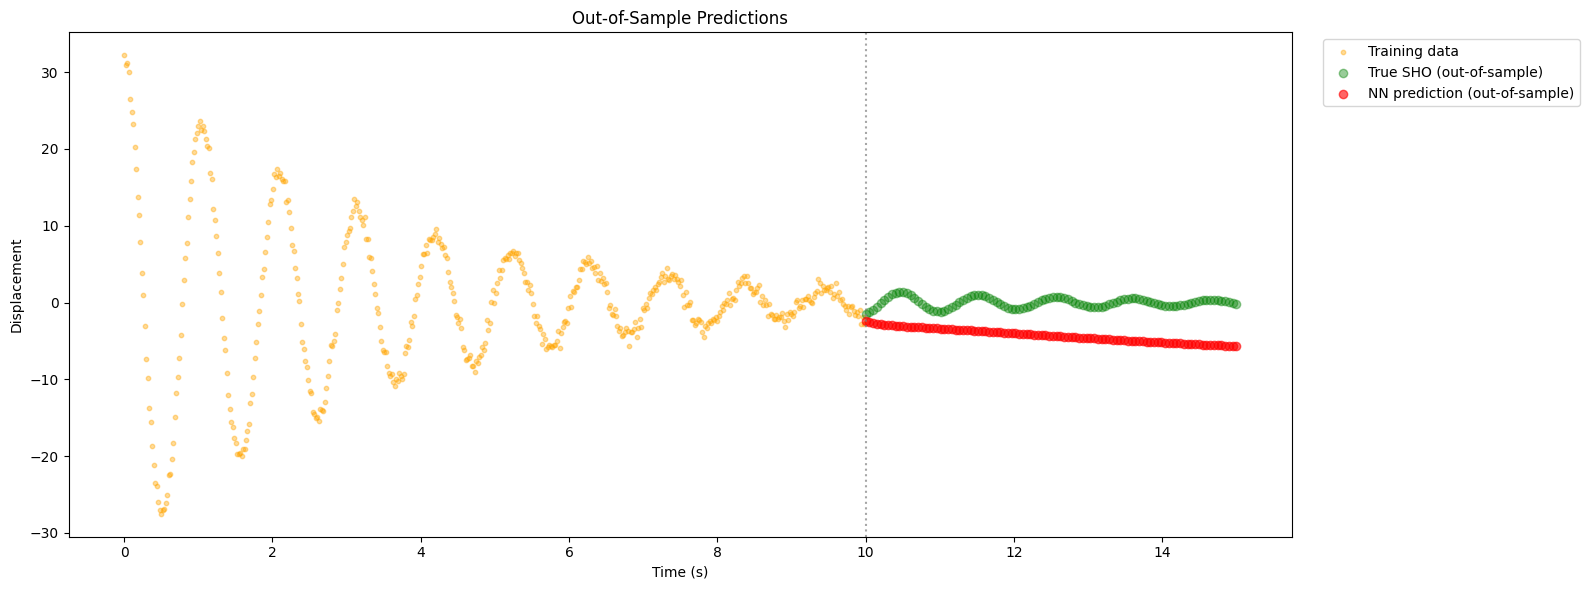

In [14]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.scatter(t, x_noisy, s=10, color="orange", alpha=0.4, label="Training data")
ax.scatter(t_out, x_out_true, color="green", alpha=0.4, label="True SHO (out-of-sample)")
ax.scatter(t_out, x_out_pred, color="red", alpha=0.6, label="NN prediction (out-of-sample)")
ax.axvline(t_end, color="gray", linestyle=":", alpha=0.7)  # marks end of training range
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement")
ax.set_title("Out-of-Sample Predictions")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()

**Insights**
- For values inside the training range predictions look good
- Model seems to overfit, because it's bad at predicting values outside the training range

### Physics Informed Neural Network

In [17]:
import torch
import torch.nn as nn

class PINN(nn.Module):
    def __init__(self, hidden_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, t):
        return self.net(t)

model = PINN()

In [18]:
# Data points: your existing noisy measurements
t_data = torch.tensor(t, dtype=torch.float32).reshape(-1, 1)
x_data = torch.tensor(x_noisy, dtype=torch.float32).reshape(-1, 1)

t_mean, t_std = t_data.mean(), t_data.std()
x_mean, x_std = x_data.mean(), x_data.std()

t_data_norm = (t_data - t_mean) / t_std
x_data_norm = (x_data - x_mean) / x_std

# Collocation points: dense grid where we enforce the physics
# These can extend BEYOND the data range -- this is what lets PINNs extrapolate
t_colloc = torch.linspace(t_start, t_end + 5, 1000).reshape(-1, 1)
t_colloc_norm = ((t_colloc - t_mean) / t_std).requires_grad_(True)  # need grad for autodiff

In [19]:
def physics_residual(model, t_norm, omega_0, zeta, t_std, x_std, x_mean):
    """
    Computes x'' + 2*zeta*omega_0*x' + omega_0^2 * x = 0
    correcting for the chain rule introduced by normalization.
    """
    x_norm = model(t_norm)

    dx_norm = torch.autograd.grad(x_norm, t_norm, grad_outputs=torch.ones_like(x_norm),
                                   create_graph=True)[0]
    d2x_norm = torch.autograd.grad(dx_norm, t_norm, grad_outputs=torch.ones_like(dx_norm),
                                    create_graph=True)[0]

    # Chain rule (see derivation from earlier in the conversation):
    # dx/dt   = (x_std / t_std)   * dx_norm/dt_norm
    # d2x/dt2 = (x_std / t_std^2) * d2x_norm/dt_norm2
    dx_dt   = (x_std / t_std)    * dx_norm
    d2x_dt2 = (x_std / t_std**2) * d2x_norm
    x_real  = x_norm * x_std + x_mean

    residual = d2x_dt2 + 2 * zeta * omega_0 * dx_dt + (omega_0**2) * x_real
    return residual


def ic_loss(model, t_mean, t_std, x_mean, x_std, x0, v0):
    """
    Enforces x(0) = x0 and x'(0) = v0
    """
    t0 = torch.tensor([[0.0]], requires_grad=True)
    t0_norm = (t0 - t_mean) / t_std

    x0_pred_norm = model(t0_norm)
    x0_pred_real = x0_pred_norm * x_std + x_mean

    dx0_norm = torch.autograd.grad(x0_pred_norm, t0_norm,
                                    grad_outputs=torch.ones_like(x0_pred_norm),
                                    create_graph=True)[0]
    v0_pred_real = (x_std / t_std) * dx0_norm

    loss_x0 = (x0_pred_real - x0)**2
    loss_v0 = (v0_pred_real - v0)**2

    return loss_x0.squeeze() + loss_v0.squeeze()

In [20]:
# --- Initial conditions for the DAMPED case ---
# x(t)  = A * exp(-zeta*omega_0*t) * cos(omega_d*t - phi)
# x'(0) = A * [ -zeta*omega_0*cos(phi) + omega_d*sin(phi) ]   (derivative of the product,
#                                                                evaluated at t=0)
zeta = gamma  # renaming for clarity vs. the omega/gamma variables in your data-gen code

x0_true = A * np.cos(phi)
v0_true = A * (-zeta * omega_0 * np.cos(phi) + omega_d * np.sin(phi))

x0_true_t = torch.tensor(x0_true, dtype=torch.float32)
v0_true_t = torch.tensor(v0_true, dtype=torch.float32)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

n_epochs = int(2e5)
lambda_physics = 5e-7
lambda_ic = 10e-6

loss_data, loss_physics, loss_ic, loss_total = [], [], [], []

for epoch in range(n_epochs):
    optimizer.zero_grad()

    x_pred_norm = model(t_data_norm)
    loss_data = criterion(x_pred_norm, x_data_norm)

    residual = physics_residual(model, t_colloc_norm, omega_0, zeta, t_std, x_std, x_mean)
    loss_physics = torch.mean(residual**2)

    loss_ic = ic_loss(model, t_mean, t_std, x_mean, x_std, x0_true_t, v0_true_t)

    loss = loss_data + lambda_physics * loss_physics + lambda_ic * loss_ic
    loss.backward()
    optimizer.step()

    loss_data.append(loss_data.item())
    loss_physics.append(loss_physics.item())
    loss_ic.append(loss_ic.item())
    loss_total.append(loss.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} | Total: {loss.item():.5f} | "
              f"Data: {loss_data.item():.5f} | Physics: {loss_physics.item():.5f} | "
              f"IC: {loss_ic.item():.5f}")

Epoch 500/200000 | Total: 1.00674 | Data: 0.99641 | Physics: 48.74913 | IC: 1030.29285
Epoch 1000/200000 | Total: 1.00374 | Data: 0.99412 | Physics: 85.48409 | IC: 957.45477
Epoch 1500/200000 | Total: 0.99249 | Data: 0.98466 | Physics: 290.85529 | IC: 768.65875
Epoch 2000/200000 | Total: 0.95894 | Data: 0.95132 | Physics: 304.50110 | IC: 747.10583
Epoch 2500/200000 | Total: 0.74760 | Data: 0.73508 | Physics: 1611.99829 | IC: 1171.05908
Epoch 3000/200000 | Total: 0.46962 | Data: 0.45469 | Physics: 19026.33594 | IC: 541.89899
Epoch 3500/200000 | Total: 0.36097 | Data: 0.34563 | Physics: 23118.94141 | IC: 378.46402
Epoch 4000/200000 | Total: 0.29034 | Data: 0.27483 | Physics: 27205.18164 | IC: 190.19571
Epoch 4500/200000 | Total: 0.25877 | Data: 0.24359 | Physics: 28628.92188 | IC: 86.38370
Epoch 5000/200000 | Total: 0.23469 | Data: 0.21928 | Physics: 29782.35938 | IC: 51.36632
Epoch 5500/200000 | Total: 0.21717 | Data: 0.20120 | Physics: 31274.99023 | IC: 33.30563
Epoch 6000/200000 | Tot

In [24]:
losses_data

[1.0047847032546997,
 1.004057765007019,
 1.0033766031265259,
 1.0027415752410889,
 1.0021523237228394,
 1.0016088485717773,
 1.0011109113693237,
 1.0006576776504517,
 1.0002483129501343,
 0.9998813271522522,
 0.9995551109313965,
 0.9992678761482239,
 0.9990174770355225,
 0.9988015294075012,
 0.99861741065979,
 0.9984622001647949,
 0.9983333945274353,
 0.9982280135154724,
 0.998143196105957,
 0.998076319694519,
 0.9980246424674988,
 0.9979860186576843,
 0.9979578852653503,
 0.9979384541511536,
 0.9979257583618164,
 0.9979182481765747,
 0.9979144930839539,
 0.997913122177124,
 0.9979133009910583,
 0.9979139566421509,
 0.99791419506073,
 0.997913658618927,
 0.9979119896888733,
 0.9979088306427002,
 0.9979040622711182,
 0.9978978037834167,
 0.9978903532028198,
 0.9978818297386169,
 0.9978727102279663,
 0.997863233089447,
 0.997853696346283,
 0.9978447556495667,
 0.9978365302085876,
 0.9978291392326355,
 0.9978229999542236,
 0.9978180527687073,
 0.9978143572807312,
 0.9978116750717163,
 0.

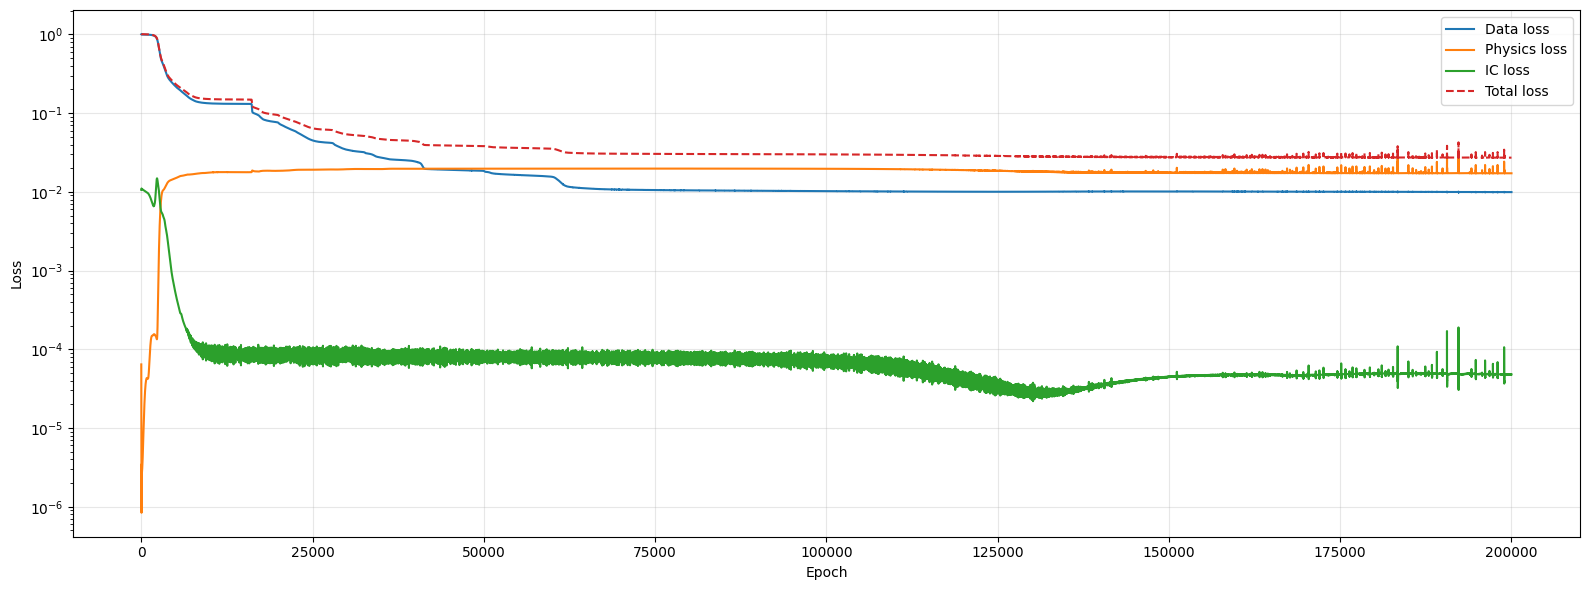

In [25]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(losses_data, label="Data loss")
ax.plot(np.array(losses_physics) * lambda_physics, label="Physics loss")
ax.plot(np.array(losses_ic) * lambda_ic, label="IC loss")
ax.plot(losses_total, label="Total loss", linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

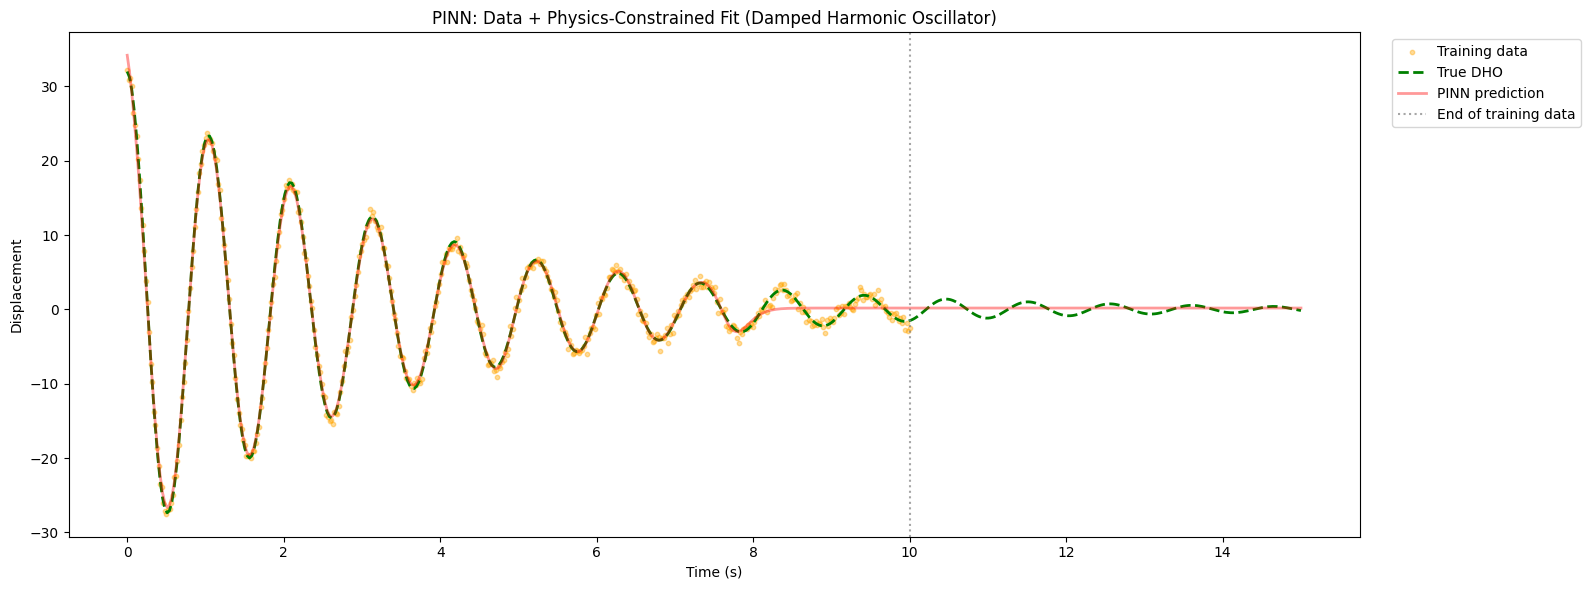

In [26]:
model.eval()
t_test = np.linspace(t_start, t_end + 5, 500)  # extends past training data!
t_test_tensor = torch.tensor(t_test, dtype=torch.float32).reshape(-1, 1)
t_test_norm = (t_test_tensor - t_mean) / t_std

with torch.no_grad():
    x_pred_norm = model(t_test_norm)
    x_pred = (x_pred_norm * x_std + x_mean).numpy().flatten()

# True DAMPED solution, using the same A, zeta, omega_0, omega_d, phi as the data-gen cell
x_true_test = A * np.exp(-zeta * omega_0 * t_test) * np.cos(omega_d * t_test - phi)

fig, ax = plt.subplots(figsize=(16, 6))
ax.scatter(t, x_noisy, s=10, color="orange", alpha=0.4, label="Training data")
ax.plot(t_test, x_true_test, color="green", linewidth=2, linestyle="--", label="True DHO")
ax.plot(t_test, x_pred, color="red", linewidth=2, alpha=0.4, label="PINN prediction")
ax.axvline(t_end, color="gray", linestyle=":", alpha=0.7, label="End of training data")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement")
ax.set_title("PINN: Data + Physics-Constrained Fit (Damped Harmonic Oscillator)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()